# Credit Risk Model: Predicting Loan Default

**Goal:** estimate the probability that a loan applicant will default (PD), then turn that into a lending decision and a credit score.

**Data:** 4,455 loan applications from a Spanish bank ([CreditScoring dataset](https://github.com/gastonstat/CreditScoring)). Each row has the applicant's income, expenses, assets, debt, job and housing situation, the loan amount, the price of the item being financed, and whether the loan was repaid (`good`) or defaulted (`bad`).

**What this notebook covers**

1. Cleaning and decoding the raw data
2. Exploratory analysis of who defaults
3. Feature engineering with standard credit ratios (loan-to-value, debt-to-income, payment burden)
4. Three models: logistic regression (the industry baseline), random forest and LightGBM
5. Credit-risk metrics: ROC-AUC, Gini, KS statistic, Brier score and calibration
6. Choosing an approval cut-off by **expected profit**, not by accuracy
7. Explaining predictions with SHAP
8. Converting PD into a **points-based credit score** and risk grades A–E

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score, brier_score_loss
from sklearn.calibration import calibration_curve

RANDOM_STATE = 42

# Chart style: colourblind-safe palette (validated), thin marks, light grid
COLORS = {"Logistic regression": "#2a78d6", "Random forest": "#eb6834", "LightGBM": "#13875f"}
GOOD, BAD = "#2a78d6", "#eb6834"
INK, MUTED, GRID = "#1c2733", "#5b6875", "#e3e7ea"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.titleweight": "bold", "axes.titlesize": 12, "axes.titlelocation": "left",
    "font.size": 10, "lines.linewidth": 2, "legend.frameon": False,
})

## 1. Load and clean the data

The raw file stores categories as numeric codes and uses `99999999` for missing values. Decode both so the data reads like a loan file.

In [2]:
raw = pd.read_csv("data/credit_scoring.csv")
print(raw.shape)
raw.head()

(4455, 14)


,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [3]:
df = raw.copy()
df.columns = df.columns.str.lower()

# Status: 1 = repaid, 2 = defaulted, 0 = unknown (1 row) -> drop the unknown
df = df[df["status"] != 0].copy()
df["default"] = (df["status"] == 2).astype(int)
df = df.drop(columns="status")

maps = {
    "home": {1: "rent", 2: "owner", 3: "private", 4: "ignore", 5: "parents", 6: "other", 0: "unknown"},
    "marital": {1: "single", 2: "married", 3: "widow", 4: "separated", 5: "divorced", 0: "unknown"},
    "records": {1: "no", 2: "yes"},
    "job": {1: "fixed", 2: "part-time", 3: "freelance", 4: "other", 0: "unknown"},
}
for col, m in maps.items():
    df[col] = df[col].map(m)

for col in ["income", "assets", "debt"]:
    df[col] = df[col].replace(99999999, np.nan)

df = df.rename(columns={"time": "term_months", "records": "has_arrears_record", "amount": "loan_amount", "price": "item_price"})
print(f"{len(df):,} loans  |  default rate {df['default'].mean():.1%}")
print("Missing values:", df.isna().sum()[lambda s: s > 0].to_dict())
df.head()

4,454 loans  |  default rate 28.2%
Missing values: {'income': 34, 'assets': 47, 'debt': 18}


,seniority,home,term_months,age,marital,has_arrears_record,job,expenses,income,assets,debt,loan_amount,item_price,default
0,9,rent,60,30,married,no,freelance,73,129.0,0.0,0.0,800,846,0
1,17,rent,60,58,widow,no,fixed,48,131.0,0.0,0.0,1000,1658,0
2,10,owner,36,46,married,yes,freelance,90,200.0,3000.0,0.0,2000,2985,1
3,0,rent,60,24,single,no,fixed,63,182.0,2500.0,0.0,900,1325,0
4,0,rent,36,26,single,no,fixed,46,107.0,0.0,0.0,310,910,0


## 2. Who defaults?

About 28% of loans in the file defaulted, so the classes are imbalanced but not extreme. The charts below compare default rates across the variables a credit officer would look at first.

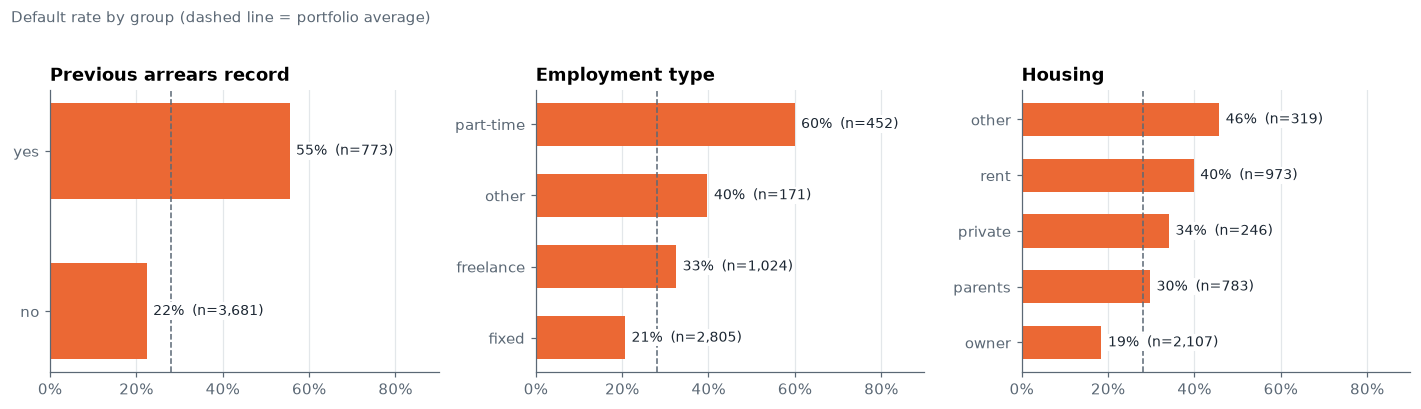

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, col, title in zip(axes, ["has_arrears_record", "job", "home"],
                          ["Previous arrears record", "Employment type", "Housing"]):
    rate = df.groupby(col)["default"].agg(["mean", "size"])
    rate = rate[rate["size"] >= 30].sort_values("mean")
    ax.barh(rate.index, rate["mean"], color=BAD, height=0.6)
    for y, (v, n) in enumerate(zip(rate["mean"], rate["size"])):
        ax.text(v + 0.015, y, f"{v:.0%}  (n={n:,})", va="center", color=INK, fontsize=9,
                bbox=dict(facecolor="white", edgecolor="none", pad=1))
    ax.axvline(df["default"].mean(), color=MUTED, ls="--", lw=1)
    ax.set_xlim(0, 0.9); ax.set_title(title); ax.grid(axis="y", visible=False)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
fig.suptitle("Default rate by group (dashed line = portfolio average)", x=0.01, ha="left", color=MUTED, fontsize=10, y=1.02)
plt.tight_layout(); plt.savefig("figures/default_rate_by_group.png", bbox_inches="tight"); plt.show()

**Reading the chart:** applicants with a previous arrears record default at 55%, against 22% for those without one. Part-time workers default most often (60%), against 21% for permanent staff. Home-owners are the safest housing group (19%), while renters (40%) and "other" housing (46%) are well above average. These are the patterns the models should pick up.

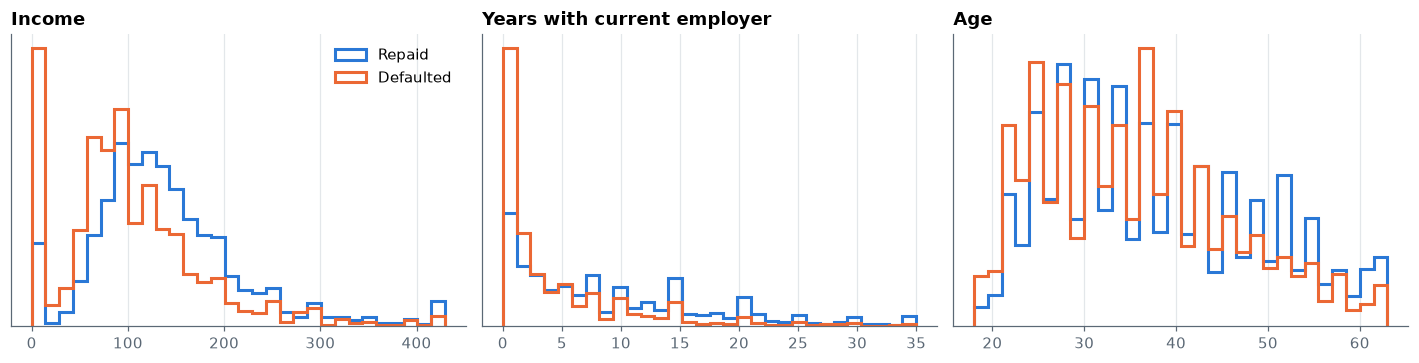

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, col, title in zip(axes, ["income", "seniority", "age"],
                          ["Income", "Years with current employer", "Age"]):
    bins = np.histogram_bin_edges(df[col].dropna().clip(upper=df[col].quantile(0.99)), bins=30)
    for label, color, name in [(0, GOOD, "Repaid"), (1, BAD, "Defaulted")]:
        ax.hist(df.loc[df["default"] == label, col].clip(upper=bins[-1]), bins=bins, density=True,
                histtype="step", lw=2, color=color, label=name)
    ax.set_title(title); ax.set_yticks([])
axes[0].legend()
plt.tight_layout(); plt.show()

Defaulters skew towards **lower income**, **shorter time with their employer** and **younger age**.

## 3. Feature engineering

Lenders rarely look at raw amounts on their own. They look at ratios that measure how stretched the borrower is. I add five standard ones:

| Feature | Formula | Why it matters |
|---|---|---|
| `loan_to_value` | loan amount / item price | Less of the borrower's own money at stake means higher risk |
| `monthly_payment` | loan amount / term | Size of the repayment |
| `payment_to_income` | monthly payment / income | Share of income going to this loan |
| `expenses_to_income` | expenses / income | How much income is already committed |
| `net_worth` | assets − debt | Buffer if income drops |

In [6]:
def add_features(d):
    d = d.copy()
    d["loan_to_value"] = d["loan_amount"] / d["item_price"]
    d["monthly_payment"] = d["loan_amount"] / d["term_months"]
    income = d["income"].replace(0, np.nan)
    d["payment_to_income"] = d["monthly_payment"] / income
    d["expenses_to_income"] = d["expenses"] / income
    d["net_worth"] = d["assets"] - d["debt"]
    return d

df = add_features(df)

CATEGORICAL = ["home", "marital", "has_arrears_record", "job"]
NUMERIC = ["seniority", "term_months", "age", "expenses", "income", "assets", "debt", "loan_amount",
           "item_price", "loan_to_value", "monthly_payment", "payment_to_income", "expenses_to_income", "net_worth"]

df[["loan_to_value", "payment_to_income", "expenses_to_income", "default"]].groupby("default").median().T \
  .rename(columns={0: "Repaid (median)", 1: "Defaulted (median)"}).round(3)

default,Repaid (median),Defaulted (median)
loan_to_value,0.737,0.833
payment_to_income,0.157,0.202
expenses_to_income,0.400,0.500


Defaulters borrowed a larger share of the item's price and commit a larger share of their income to repayments, so the ratios carry signal.

## 4. Train/test split

I hold out 20% of loans as a test set and touch it only once, at the end. All model selection uses 5-fold cross-validation on the training set.

In [7]:
X = df[CATEGORICAL + NUMERIC]
y = df["default"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f"Train: {len(X_train):,} loans ({y_train.mean():.1%} default)  |  Test: {len(X_test):,} loans ({y_test.mean():.1%} default)")

Train: 3,563 loans (28.2% default)  |  Test: 891 loans (28.2% default)


## 5. Models

- **Logistic regression** is the standard in regulated credit scoring because each coefficient can be explained to a regulator. Numeric features are log-transformed where skewed, then scaled.
- **Random forest** captures non-linear effects with little tuning.
- **LightGBM** is a gradient-boosted tree model, the usual best performer on tabular data. I tune it with a small grid search.

In [8]:
SKEWED = ["income", "assets", "debt", "loan_amount", "item_price", "expenses", "monthly_payment"]

def log_skewed(X):
    X = X.copy()
    for c in SKEWED:
        X[c] = np.log1p(X[c].clip(lower=0))
    X["net_worth"] = np.sign(X["net_worth"]) * np.log1p(X["net_worth"].abs())
    return X

from sklearn.preprocessing import FunctionTransformer

numeric_lr = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
cat_pipe = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                     ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20))])

logreg = Pipeline([
    ("log", FunctionTransformer(log_skewed)),
    ("prep", ColumnTransformer([("num", numeric_lr, NUMERIC), ("cat", cat_pipe, CATEGORICAL)])),
    ("model", LogisticRegression(C=0.5, max_iter=2000)),
])

tree_prep = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), NUMERIC),
    ("cat", cat_pipe, CATEGORICAL),
])
forest = Pipeline([("prep", tree_prep),
                   ("model", RandomForestClassifier(n_estimators=500, min_samples_leaf=5, max_features="sqrt",
                                                    n_jobs=-1, random_state=RANDOM_STATE))])

# LightGBM handles missing values natively; categories are passed as pandas categoricals
def to_lgb(X):
    X = X.copy()
    for c in CATEGORICAL:
        X[c] = X[c].astype("category")
    return X

lgbm_search = GridSearchCV(
    lgb.LGBMClassifier(n_estimators=300, random_state=RANDOM_STATE, verbose=-1, n_jobs=1),
    {"learning_rate": [0.02, 0.05], "num_leaves": [7, 15], "min_child_samples": [20, 50],
     "subsample": [0.8], "subsample_freq": [1], "colsample_bytree": [0.8]},
    scoring="roc_auc", cv=cv, n_jobs=1,
).fit(to_lgb(X_train), y_train)
print("Best LightGBM params:", {k: v for k, v in lgbm_search.best_params_.items() if k in ["learning_rate", "num_leaves", "min_child_samples"]})
print(f"Best LightGBM CV AUC: {lgbm_search.best_score_:.3f}")
lgbm = lgbm_search.best_estimator_

Best LightGBM params: {'learning_rate': 0.02, 'min_child_samples': 50, 'num_leaves': 7}
Best LightGBM CV AUC: 0.851


### Cross-validated comparison

Credit teams usually report three ranking metrics. All of them measure how well the model separates good loans from bad ones:

- **ROC-AUC:** the probability that a random defaulter gets a higher risk score than a random good payer.
- **Gini** = 2 × AUC − 1. This is the number most banks quote.
- **KS statistic:** the largest gap between the cumulative score distributions of good and bad loans.

The **Brier score** measures how accurate the probabilities themselves are (lower is better).

In [9]:
def ks_stat(y_true, p):
    fpr, tpr, _ = roc_curve(y_true, p)
    return np.max(tpr - fpr)

def credit_metrics(y_true, p):
    auc = roc_auc_score(y_true, p)
    return {"ROC-AUC": auc, "Gini": 2 * auc - 1, "KS": ks_stat(y_true, p),
            "PR-AUC": average_precision_score(y_true, p), "Brier": brier_score_loss(y_true, p)}

oof = {
    "Logistic regression": cross_val_predict(logreg, X_train, y_train, cv=cv, method="predict_proba")[:, 1],
    "Random forest": cross_val_predict(forest, X_train, y_train, cv=cv, method="predict_proba")[:, 1],
    "LightGBM": cross_val_predict(lgbm, to_lgb(X_train), y_train, cv=cv, method="predict_proba")[:, 1],
}
cv_table = pd.DataFrame({name: credit_metrics(y_train, p) for name, p in oof.items()}).T
cv_table.round(3)

,ROC-AUC,Gini,KS,PR-AUC,Brier
Logistic regression,0.838,0.676,0.528,0.667,0.141
Random forest,0.844,0.689,0.546,0.668,0.140
LightGBM,0.851,0.702,0.540,0.693,0.136


## 6. Test-set results

I refit each model on the full training set and score the untouched test set once.

In [10]:
logreg.fit(X_train, y_train)
forest.fit(X_train, y_train)
lgbm.fit(to_lgb(X_train), y_train)

test_pred = {
    "Logistic regression": logreg.predict_proba(X_test)[:, 1],
    "Random forest": forest.predict_proba(X_test)[:, 1],
    "LightGBM": lgbm.predict_proba(to_lgb(X_test))[:, 1],
}
test_table = pd.DataFrame({name: credit_metrics(y_test, p) for name, p in test_pred.items()}).T
test_table.round(3)

,ROC-AUC,Gini,KS,PR-AUC,Brier
Logistic regression,0.852,0.704,0.566,0.714,0.132
Random forest,0.849,0.698,0.591,0.691,0.136
LightGBM,0.855,0.710,0.573,0.706,0.132


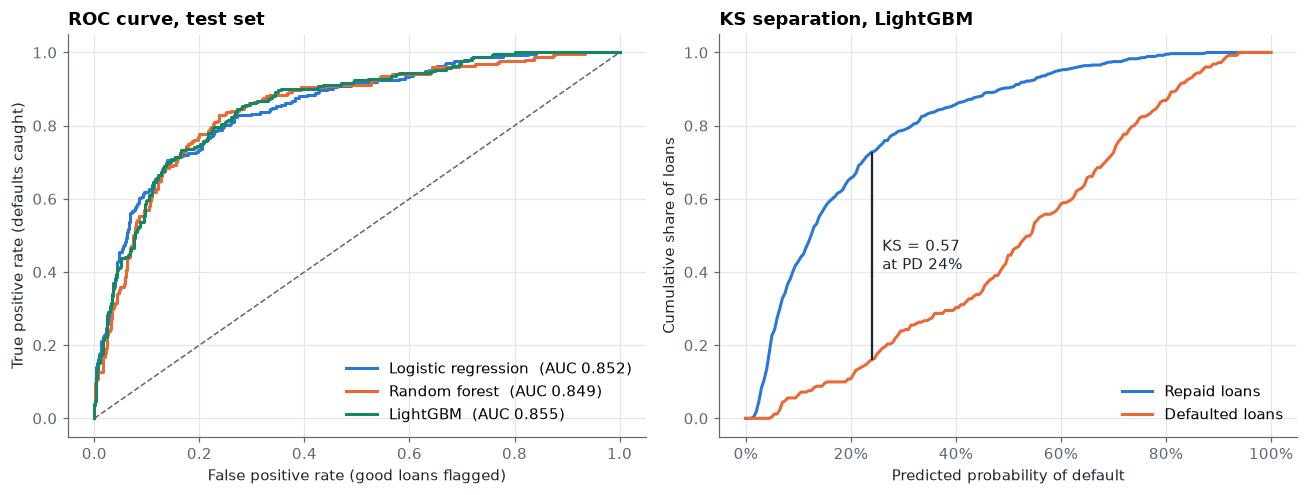

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

ax = axes[0]
for name, p in test_pred.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    ax.plot(fpr, tpr, color=COLORS[name], label=f"{name}  (AUC {roc_auc_score(y_test, p):.3f})")
ax.plot([0, 1], [0, 1], color=MUTED, lw=1, ls="--")
ax.set_xlabel("False positive rate (good loans flagged)"); ax.set_ylabel("True positive rate (defaults caught)")
ax.set_title("ROC curve, test set"); ax.legend(loc="lower right")

ax = axes[1]
p = test_pred["LightGBM"]
grid = np.linspace(0, 1, 201)
cdf_good = [(p[y_test == 0] <= t).mean() for t in grid]
cdf_bad = [(p[y_test == 1] <= t).mean() for t in grid]
gap = np.array(cdf_good) - np.array(cdf_bad)
i = gap.argmax()
ax.plot(grid, cdf_good, color=GOOD, label="Repaid loans")
ax.plot(grid, cdf_bad, color=BAD, label="Defaulted loans")
ax.vlines(grid[i], cdf_bad[i], cdf_good[i], color=INK, lw=1.5)
ax.text(grid[i] + 0.02, (cdf_good[i] + cdf_bad[i]) / 2, f"KS = {gap[i]:.2f}\nat PD {grid[i]:.0%}", color=INK, va="center")
ax.set_xlabel("Predicted probability of default"); ax.set_ylabel("Cumulative share of loans")
ax.set_title("KS separation, LightGBM"); ax.legend(loc="lower right")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

plt.tight_layout(); plt.savefig("figures/roc_ks.png", bbox_inches="tight"); plt.show()

### Are the probabilities trustworthy?

A PD model is used for pricing and capital, so a predicted 20% should mean about 1 in 5 of those loans default. The calibration plot checks this.

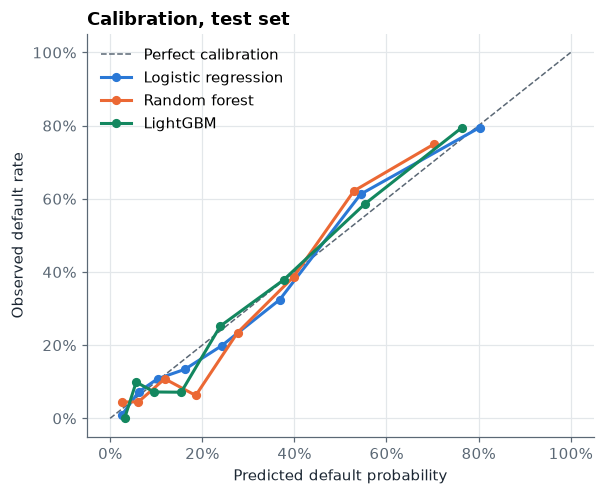

In [12]:
fig, ax = plt.subplots(figsize=(5.6, 4.6))
ax.plot([0, 1], [0, 1], color=MUTED, lw=1, ls="--", label="Perfect calibration")
for name, p in test_pred.items():
    frac, mean_p = calibration_curve(y_test, p, n_bins=8, strategy="quantile")
    ax.plot(mean_p, frac, marker="o", ms=5, color=COLORS[name], label=name)
ax.set_xlabel("Predicted default probability"); ax.set_ylabel("Observed default rate")
ax.set_title("Calibration, test set"); ax.legend(loc="upper left")
for a in (ax.xaxis, ax.yaxis):
    a.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout(); plt.show()

## 7. Choosing the approval cut-off by profit

Accuracy is the wrong target for a lender, because the two kinds of mistake cost very different amounts:

- **Approve a loan that defaults:** lose most of the loan. I assume a **loss given default (LGD) of 60%** of the loan amount.
- **Reject a loan that would have repaid:** lose the interest margin. I assume a **net margin of 15%** of the loan amount over the life of the loan.

Both numbers are illustrative assumptions. A real lender would plug in its own pricing and recovery data. I pick the PD cut-off that maximises profit on the **cross-validated training predictions**, then check it on the test set.

In [13]:
LGD, MARGIN = 0.60, 0.15

def portfolio_profit(y_true, p, amount, cutoff):
    approve = p < cutoff
    gain = np.where(y_true == 0, MARGIN * amount, -LGD * amount)
    return gain[approve].sum()

cutoffs = np.linspace(0.02, 0.98, 97)
amount_train = X_train["loan_amount"].values
profit_curve = [portfolio_profit(y_train.values, oof["LightGBM"], amount_train, c) for c in cutoffs]
best_cutoff = cutoffs[int(np.argmax(profit_curve))]

amount_test = X_test["loan_amount"].values
p_test = test_pred["LightGBM"]

def summarize(name, approve):
    gain = np.where(y_test.values == 0, MARGIN * amount_test, -LGD * amount_test)
    return {"Policy": name, "Approval rate": approve.mean(),
            "Default rate of approved": y_test.values[approve].mean(),
            "Profit": gain[approve].sum()}

policy = pd.DataFrame([
    summarize("Approve everyone", np.ones(len(y_test), bool)),
    summarize("Reject anyone with an arrears record", (X_test["has_arrears_record"] == "no").values),
    summarize(f"LightGBM, approve if PD < {best_cutoff:.0%}", p_test < best_cutoff),
]).set_index("Policy")
print(f"Profit-maximising cut-off (chosen on training CV): PD < {best_cutoff:.0%}")
policy.style.format({"Approval rate": "{:.0%}", "Default rate of approved": "{:.1%}", "Profit": "{:,.0f}"})

Profit-maximising cut-off (chosen on training CV): PD < 18%


,Approval rate,Default rate of approved,Profit
Policy,,,
Approve everyone,100%,28.2%,"-79,773"
Reject anyone with an arrears record,83%,21.8%,"-18,563"
"LightGBM, approve if PD < 18%",47%,5.9%,"37,717"


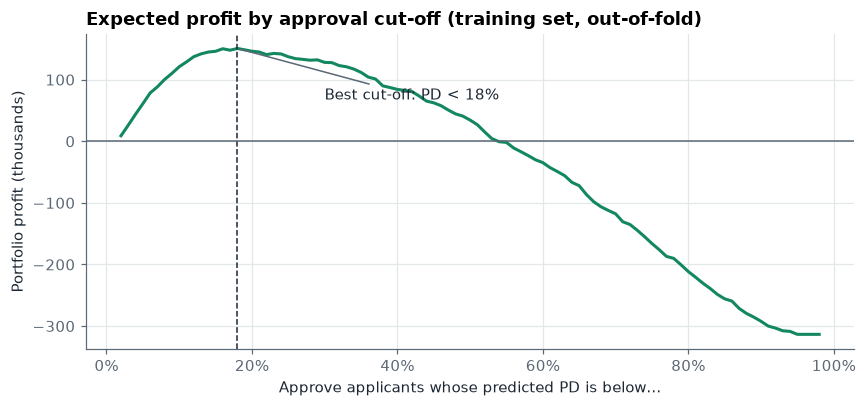

In [14]:
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(cutoffs, np.array(profit_curve) / 1e3, color=COLORS["LightGBM"])
ax.axvline(best_cutoff, color=INK, lw=1, ls="--")
ax.annotate(f"Best cut-off: PD < {best_cutoff:.0%}", xy=(best_cutoff, max(profit_curve) / 1e3),
            xytext=(best_cutoff + 0.12, max(profit_curve) / 1e3 * 0.45), color=INK,
            arrowprops=dict(arrowstyle="-", color=MUTED))
ax.axhline(0, color=MUTED, lw=1)
ax.set_xlabel("Approve applicants whose predicted PD is below…"); ax.set_ylabel("Portfolio profit (thousands)")
ax.set_title("Expected profit by approval cut-off (training set, out-of-fold)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout(); plt.savefig("figures/profit_cutoff.png", bbox_inches="tight"); plt.show()

## 8. What drives the predictions?

SHAP values show how much each feature pushed an individual applicant's risk up or down. Averaging their absolute size gives a global ranking.

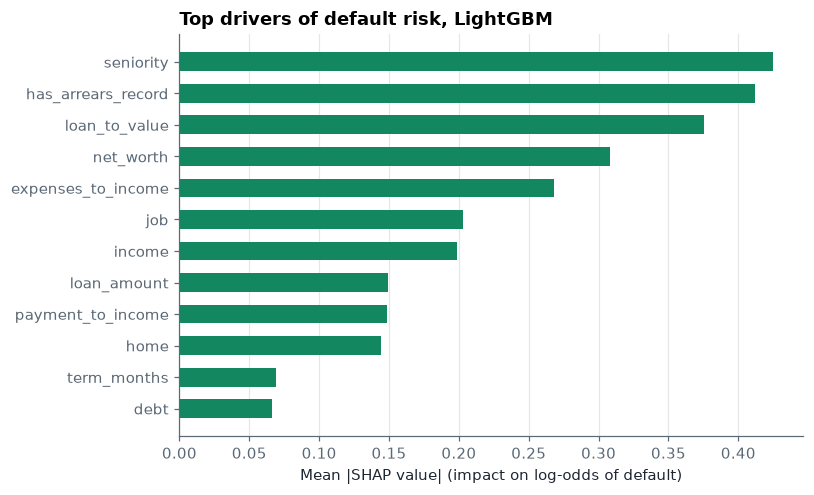

In [15]:
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer(to_lgb(X_test))
sv = shap_values.values[:, :, 1] if shap_values.values.ndim == 3 else shap_values.values

importance = pd.Series(np.abs(sv).mean(axis=0), index=X_test.columns).sort_values()
top = importance.tail(12)
fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.barh(top.index, top.values, color=COLORS["LightGBM"], height=0.6)
ax.set_xlabel("Mean |SHAP value| (impact on log-odds of default)")
ax.set_title("Top drivers of default risk, LightGBM"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.savefig("figures/shap_importance.png", bbox_inches="tight"); plt.show()

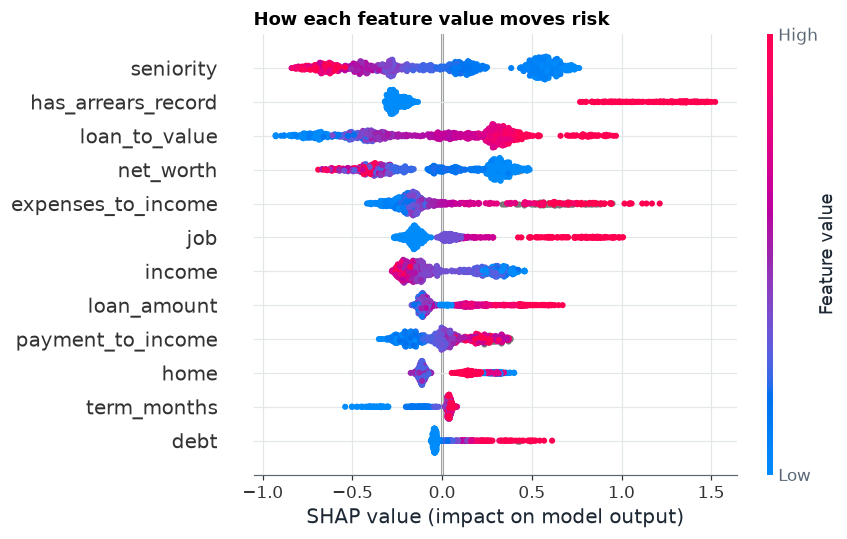

In [16]:
shap.summary_plot(sv, to_lgb(X_test).assign(**{c: X_test[c].astype("category").cat.codes for c in CATEGORICAL}),
                  max_display=12, show=False, plot_size=(8, 5))
plt.title("How each feature value moves risk", loc="left", fontweight="bold")
plt.tight_layout(); plt.show()

## 9. From probability to credit score

Customers and loan officers work with **scores**, not probabilities. I use the standard scorecard scaling:

- A score of **600** means odds of 50 good loans to 1 bad.
- Every **20 points** (the "points to double the odds", PDO) doubles the odds of repaying.

score = offset + factor × ln(odds of repaying), where factor = PDO / ln 2.

Scores are then grouped into risk grades A (safest) to E.

In [17]:
PDO, BASE_SCORE, BASE_ODDS = 20, 600, 50
factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)

def pd_to_score(p):
    p = np.clip(p, 1e-4, 1 - 1e-4)
    return np.round(offset + factor * np.log((1 - p) / p)).astype(int)

scores = pd_to_score(p_test)
edges = np.quantile(scores, [0, 0.2, 0.4, 0.6, 0.8, 1])
grades = pd.cut(scores, bins=edges, labels=["E", "D", "C", "B", "A"], include_lowest=True)

grade_table = (pd.DataFrame({"grade": grades, "score": scores, "default": y_test.values})
               .groupby("grade", observed=True)
               .agg(score_min=("score", "min"), score_max=("score", "max"), loans=("default", "size"), default_rate=("default", "mean"))
               .sort_index(ascending=False))
grade_table.style.format({"default_rate": "{:.1%}"})

,score_min,score_max,loans,default_rate
grade,,,,
A,568,609,173,1.7%
B,543,567,178,10.1%
C,518,542,176,15.3%
D,484,517,185,40.5%
E,408,483,179,71.5%


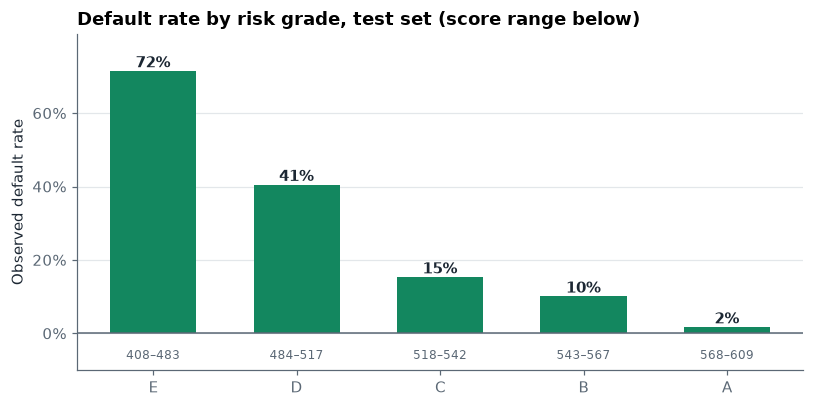

In [18]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))
gt = grade_table.iloc[::-1]
bars = ax.bar(gt.index.astype(str), gt["default_rate"], color=COLORS["LightGBM"], width=0.6)
for b, (lo, hi, r) in zip(bars, zip(gt["score_min"], gt["score_max"], gt["default_rate"])):
    ax.text(b.get_x() + b.get_width() / 2, r + 0.01, f"{r:.0%}", ha="center", color=INK, fontsize=10, fontweight="bold")
    ax.text(b.get_x() + b.get_width() / 2, -0.07, f"{lo}–{hi}", ha="center", color=MUTED, fontsize=8)
ax.set_ylim(-0.1, max(gt["default_rate"]) + 0.1); ax.axhline(0, color=MUTED, lw=1)
ax.set_yticks([0, 0.2, 0.4, 0.6]); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_ylabel("Observed default rate"); ax.set_title("Default rate by risk grade, test set (score range below)")
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.savefig("figures/risk_grades.png", bbox_inches="tight"); plt.show()

## 10. Scoring a new applicant

The whole pipeline wrapped in one function: raw application in, PD, score, grade and decision out.

In [19]:
def score_applicant(application: dict) -> dict:
    row = add_features(pd.DataFrame([application]))[CATEGORICAL + NUMERIC]
    p = float(lgbm.predict_proba(to_lgb(row).astype(to_lgb(X_train).dtypes.to_dict()))[:, 1][0])
    s = int(pd_to_score(np.array([p]))[0])
    grade = "A" if s > edges[4] else "B" if s > edges[3] else "C" if s > edges[2] else "D" if s > edges[1] else "E"
    return {"probability_of_default": round(p, 3), "score": s, "grade": grade,
            "decision": "approve" if p < best_cutoff else "decline"}

applicants = {
    "Steady employee, home-owner": dict(seniority=12, home="owner", term_months=36, age=45, marital="married",
        has_arrears_record="no", job="fixed", expenses=60, income=180, assets=8000, debt=0, loan_amount=900, item_price=1500),
    "New freelancer with arrears, renting": dict(seniority=1, home="rent", term_months=60, age=24, marital="single",
        has_arrears_record="yes", job="freelance", expenses=75, income=90, assets=0, debt=0, loan_amount=1400, item_price=1450),
}
pd.DataFrame({name: score_applicant(a) for name, a in applicants.items()}).T

,probability_of_default,score,grade,decision
"Steady employee, home-owner",0.023,595,A,approve
"New freelancer with arrears, renting",0.847,438,E,decline


## 11. Results and takeaways

- **LightGBM** has the highest test AUC (0.855) and Gini (0.71). **Logistic regression** is only 0.003 AUC behind while staying fully explainable, which is why banks often keep it as the production scorecard and use boosted trees as a challenger model.
- Years with the current employer and a previous arrears record are the two strongest drivers. Three of the engineered features come next: **loan-to-value**, **net worth** and **expenses-to-income**.
- On the test set, approving everyone **loses money** and rejecting everyone with an arrears record still loses money. Approving only applicants with PD under 18% cuts the default rate of approved loans to about 6% and **turns the portfolio profitable**. Profit depends on the LGD and margin assumptions, so the cut-off should be re-tuned with a lender's real numbers.
- Observed default rates fall steadily from grade E (72%) to grade A (2%), so the score works for pricing and limits as well as yes/no decisions.

**Next steps:** monitor population stability (PSI) on new applications, test fairness across age and marital status before any real use, and replace the illustrative LGD and margin with the lender's own figures.